In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Distribution embedding

{'000': 9, '001': 29, '010': 130, '011': 239, '100': 303, '101': 218, '110': 72, '111': 24}


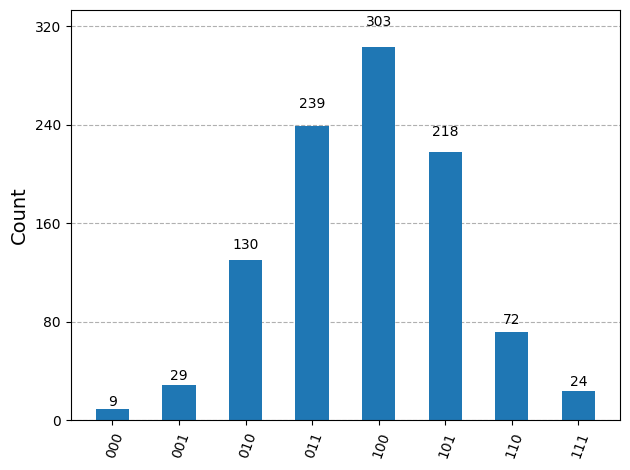

In [2]:
from distributions import MinMaxBinning, SingleGaussian
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _sample = SingleGaussian(shots = _size)
    return MinMaxBinning(_sample, _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN evaluation

Total Parameters: 12


/tmp/ipykernel_276123/1288343454.py:113: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


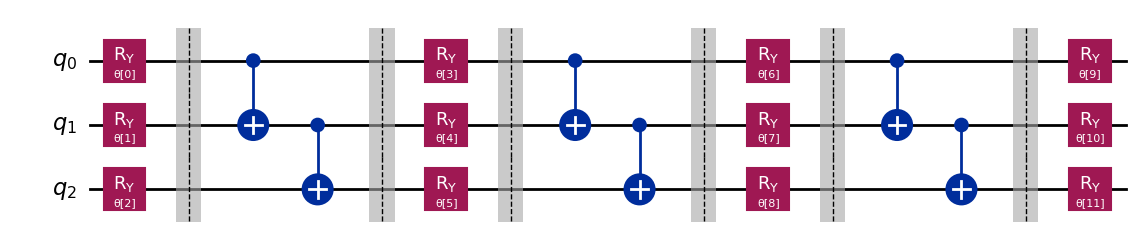

In [14]:
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RYGate

def build_tree_circuit(n_qubits, angles):
    """
    Builds the Balanced Tree (Binary) state preparation.
    Requires (2^N - 1) angles.
    """
    num_angles = 2**n_qubits - 1
    if len(angles) != num_angles:
        raise ValueError(f"{n_qubits} qubits require {num_angles} angles.")
        
    qc = QuantumCircuit(n_qubits, name="Tree")
    qc.h(range(num_qubits))
    angle_idx = 0
    
    # Iterate through the levels of the tree (one level per qubit)
    for level in range(n_qubits):
        # The qubit we are targeting at this level
        # We start at the Most Significant Qubit (MSB) and work down
        target_qubit = n_qubits - 1 - level
        
        # At level 'L', we have 2^L gates to place
        num_gates_this_level = 2**level
        
        # The controls are all the qubits we have already processed
        control_qubits = list(range(n_qubits - level, n_qubits))
        
        for gate_idx in range(num_gates_this_level):
            theta = 2 * angles[angle_idx]
            angle_idx += 1
            
            if level == 0:
                # The root of the tree (Level 0) has no controls
                qc.ry(theta, target_qubit)
            else:
                # The control state is the binary representation of the gate index
                ctrl_state_str = format(gate_idx, f'0{level}b')
                
                mc_ry = RYGate(theta).control(
                    num_ctrl_qubits=level, 
                    ctrl_state=ctrl_state_str
                )
                qc.append(mc_ry, control_qubits + [target_qubit])
                
    return qc

def build_ladder_circuit(n_qubits, angles):
    """
    Builds the Nested Ladder (Unary) state preparation.
    Requires (2^N - 1) angles.
    """
    num_angles = 2**n_qubits - 1
    if len(angles) != num_angles:
        raise ValueError(f"{n_qubits} qubits require {num_angles} angles.")
        
    qc = QuantumCircuit(n_qubits, name="Ladder")
    qc.h(range(num_qubits))
    
    # We iterate through each angle to peel off the amplitude for state 'i'
    for i in range(num_angles):
        # The angle to apply
        theta = 2 * angles[i]
        
        # We find which qubit needs to be rotated.
        # In a sequential ladder, we find the first bit that differs 
        # between the binary representation of i and i+1.
        # To keep it universally scalable and match the math, we use 
        # Gray Code or sequential binary control. Here we use standard binary.
        binary_str = format(i, f'0{n_qubits}b')
        
        # Find the least significant qubit to target (moving right to left)
        # We rotate the first '0' we find in the binary string.
        target_idx = binary_str.rfind('0')
        target_qubit = n_qubits - 1 - target_idx
        
        # All qubits to the left of the target in the binary string are our controls
        control_qubits = list(range(target_qubit + 1, n_qubits))
        
        if not control_qubits:
            # First split (x_1), no controls needed
            qc.ry(theta, target_qubit)
        else:
            # Extract the control state from the binary string
            ctrl_state_str = binary_str[:target_idx]
            
            # Create a multi-controlled RY gate triggered only by the specific path
            mc_ry = RYGate(theta).control(
                num_ctrl_qubits=len(control_qubits), 
                ctrl_state=ctrl_state_str
            )
            # Append gate: controls first, then target
            qc.append(mc_ry, control_qubits + [target_qubit])
            
    return qc

from qiskit.circuit.library import NLocal, RYGate
from qiskit.circuit import ParameterVector

from qiskit.circuit.library import RealAmplitudes

def get_efficient_qgan_generator(num_qubits, reps=2):
    """
    Constructs an efficient generator for probability distributions.
    
    - RealAmplitudes: Uses RY rotations and CX/CZ entanglement.
    - entanglement='linear': Entangles neighbors (0,1), (1,2), etc.
    - This keeps amplitudes real and is very hardware-efficient.
    """
    
    # RealAmplitudes is a specialized subclass of NLocal
    # that is strictly defined for real-valued probability amplitudes.
    ansatz = RealAmplitudes(
        num_qubits=num_qubits,
        entanglement='linear', # 'linear' or 'pairwise' are both great
        reps=reps,
        insert_barriers=True
    )
    
    return ansatz


# Example Usage: 4 qubits, 3 layers of learning
num_qubits = 3
qc = get_efficient_qgan_generator(num_qubits, reps=3)

# To see the parameter mapping and gate structure:
print(f"Total Parameters: {qc.num_parameters}")
qc.decompose().draw('mpl')

In [15]:
# num_qubits = 3
# angles = ParameterVector("θ", length = 2**num_qubits - 1)
# qc = build_ladder_circuit(num_qubits, angles)
# qc.draw("mpl")

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='sigmoid') 
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from qgan import QGAN
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [18]:
epochs = 2000
model.discriminator_lr = 1e-2
model.fit(epochs = epochs, shots = 2**10, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260414_182711
Training started


100%|██████████| 2000/2000 [09:19<00:00,  3.57it/s]

Training completed


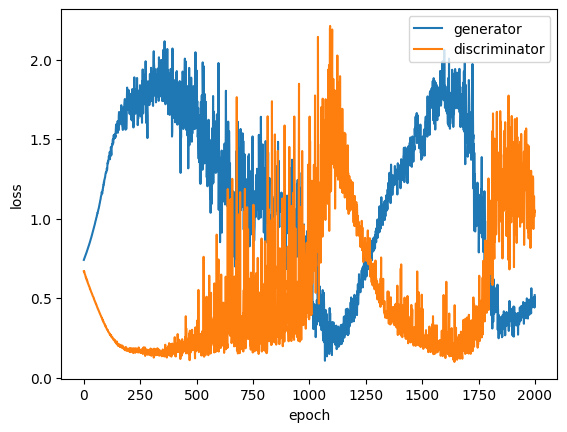

In [19]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()